# Đồ án Môn học DS108: Xây dựng Mô hình Học máy (Machine Learning)
**Giai đoạn 3: Feature Engineering (Wilson Score) & Predictive Modeling**

Notebook này tiếp nối kết quả từ quá trình EDA, với mục tiêu xây dựng các mô hình học máy để dự đoán chất lượng/độ thành công của một tựa game dựa trên các đặc trưng về giá và thể loại.
Các bước chính:
1. **Feature Engineering:** Xây dựng thang điểm độ tin cậy **Wilson Score** thay thế cho Rating Ratio đơn thuần.
2. **Data Preparation:** Lựa chọn đặc trưng (Feature Selection), chia tập dữ liệu (Train/Test Split) và Chuẩn hóa (Scaling).
3. **Model Training:** Huấn luyện 3 mô hình tiêu biểu: Linear Regression (Baseline), Random Forest (Ensemble) và XGBoost (Gradient Boosting).
4. **Evaluation:** Đánh giá hiệu suất và trích xuất độ quan trọng của đặc trưng (Feature Importance).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện Machine Learning từ scikit-learn và xgboost
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Bạn cần cài đặt xgboost nếu chưa có: pip install xgboost
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Các thư viện Machine Learning đã sẵn sàng!")

✅ Các thư viện Machine Learning đã sẵn sàng!


In [2]:
# Tải dữ liệu thành phẩm từ Giai đoạn 2
INPUT_PATH = '../data/processed/steam_games_with_genres.csv'

try:
    df = pd.read_csv(INPUT_PATH)
except FileNotFoundError:
    df = pd.read_csv('steam_games_with_genres.csv') # Fallback

print(f"📊 Đã tải dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột.")

📊 Đã tải dữ liệu: 3868 dòng, 52 cột.


## 1. Feature Engineering: Tính toán Wilson Score
Công thức Wilson Score Interval tính toán giới hạn dưới của khoảng tin cậy (Lower bound of confidence interval) cho một tỷ lệ.
- Những game có 90% positive / 100 review sẽ bị hạ điểm (vì độ tin cậy thấp).
- Những game có 90% positive / 100,000 review sẽ giữ nguyên mức ~90% (vì mẫu đủ lớn, độ tin cậy cực cao).

✅ Wilson Score đã có sẵn trong tập dữ liệu.


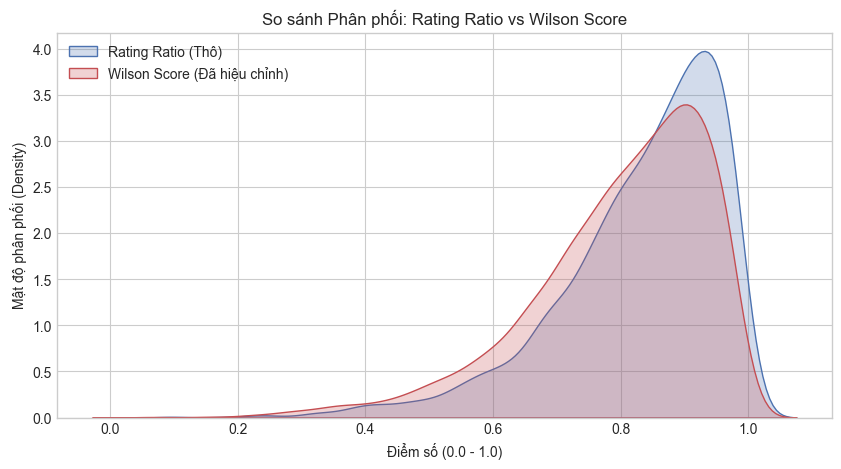

In [3]:
# Vì Wilson Score đã được tính toán và lưu trữ từ Giai đoạn 1 (Notebook 01), 
# chúng ta chỉ cần xác nhận sự tồn tại của cột này trong dữ liệu.

if 'wilson_score' not in df.columns:
    print("⚠️ Cảnh báo: Cột 'wilson_score' không tìm thấy. Đang tính toán lại...")
    z = 1.95996
    phat = df['positive_ratings'] / df['total_ratings']
    n = df['total_ratings']
    z2 = z**2
    df['wilson_score'] = (phat + z2/(2*n) - z * np.sqrt((phat*(1-phat) + z2/(4*n))/n)) / (1 + z2/n)
else:
    print("✅ Wilson Score đã có sẵn trong tập dữ liệu.")

# Trực quan hóa sự khác biệt giữa Rating Ratio thô và Wilson Score để minh chứng cho việc chống Survivorship Bias
plt.figure(figsize=(10, 5))
sns.kdeplot(df['rating_ratio'], fill=True, label='Rating Ratio (Thô)', color='#4C72B0')
sns.kdeplot(df['wilson_score'], fill=True, label='Wilson Score (Đã hiệu chỉnh)', color='#C44E52')
plt.title('So sánh Phân phối: Rating Ratio vs Wilson Score')
plt.xlabel('Điểm số (0.0 - 1.0)')
plt.ylabel('Mật độ phân phối (Density)')
plt.legend()
plt.show()

## 2. Chuẩn bị Dữ liệu (Data Preparation)
Lựa chọn các biến đặc trưng (X) để dự đoán điểm Wilson Score (y).
- **Không dùng:** `positive_ratings`, `negative_ratings`, `total_ratings`, `rating_ratio` (Vì đây là rò rỉ dữ liệu - Data Leakage, chúng ta không thể biết trước số lượt review khi game vừa ra mắt).
- **Đặc trưng (Features):** Giá tiền (`price`), Miễn phí hay không (`is_free`), Năm (`year`), và Toàn bộ các cột thể loại (`genre_...`).

In [4]:
# 1. Xác định Features (X) và Target (y)
genre_cols = [col for col in df.columns if col.startswith('genre_')]
features = ['price', 'is_free', 'year'] + genre_cols

X = df[features]
y = df['wilson_score']

print(f"Số lượng đặc trưng (Features) đưa vào mô hình: {len(features)}")

# 2. Train/Test Split (80% Huấn luyện, 20% Kiểm thử)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Chuẩn hóa dữ liệu (Standardization) cho các biến liên tục
scaler = StandardScaler()

# Chỉ scale 'price' và 'year' (không scale các biến nhị phân One-Hot)
cols_to_scale = ['price', 'year']

# Copy để tránh warning
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(f"Kích thước tập Huấn luyện (Train): {X_train_scaled.shape}")
print(f"Kích thước tập Kiểm thử (Test): {X_test_scaled.shape}")

Số lượng đặc trưng (Features) đưa vào mô hình: 25
Kích thước tập Huấn luyện (Train): (3094, 25)
Kích thước tập Kiểm thử (Test): (774, 25)


## 3. Huấn luyện Mô hình (Model Training & Evaluation)
Thiết lập 3 mô hình và xây dựng hàm đánh giá tự động các chỉ số:
- **RMSE (Root Mean Squared Error):** Sai số trung bình.
- **MAE (Mean Absolute Error):** Sai số tuyệt đối.
- **R² Score:** Mức độ giải thích của mô hình (càng gần 1 càng tốt).

In [5]:
# Khởi tạo Dictionary để lưu kết quả
results = {}

def evaluate_model(name, model, X_t, y_t):
    y_pred = model.predict(X_t)
    rmse = np.sqrt(mean_squared_error(y_t, y_pred))
    mae = mean_absolute_error(y_t, y_pred)
    r2 = r2_score(y_t, y_pred)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"--- Mô hình: {name} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}\n")
    return y_pred

# 1. Hồi quy Tuyến tính (Linear Regression - Baseline Model)
print("Đang huấn luyện Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = evaluate_model("Linear Regression", lr_model, X_test_scaled, y_test)

# 2. Random Forest Regressor
print("Đang huấn luyện Random Forest (Ensemble)...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = evaluate_model("Random Forest", rf_model, X_test_scaled, y_test)

# 3. XGBoost Regressor
print("Đang huấn luyện XGBoost (Gradient Boosting)...")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = evaluate_model("XGBoost", xgb_model, X_test_scaled, y_test)

Đang huấn luyện Linear Regression...
--- Mô hình: Linear Regression ---
RMSE: 0.1358
MAE:  0.1076
R²:   0.0756

Đang huấn luyện Random Forest (Ensemble)...
--- Mô hình: Random Forest ---
RMSE: 0.1373
MAE:  0.1067
R²:   0.0555

Đang huấn luyện XGBoost (Gradient Boosting)...
--- Mô hình: XGBoost ---
RMSE: 0.1396
MAE:  0.1082
R²:   0.0231



BẢNG TỔNG HỢP HIỆU SUẤT MÔ HÌNH:


,RMSE,MAE,R2
Linear Regression,0.135817,0.107569,0.075556
Random Forest,0.137282,0.106687,0.055497
XGBoost,0.139618,0.108158,0.023090


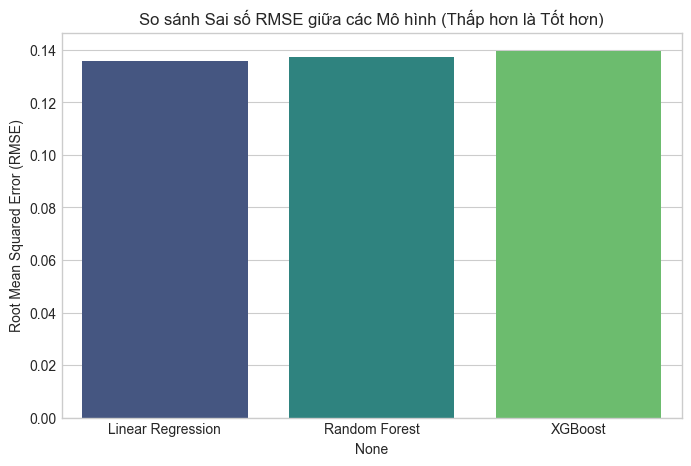

In [6]:
# Tạo DataFrame so sánh kết quả các mô hình
results_df = pd.DataFrame(results).T
print("BẢNG TỔNG HỢP HIỆU SUẤT MÔ HÌNH:")
display(results_df)

# Trực quan hóa so sánh RMSE
plt.figure(figsize=(8, 5))
sns.barplot(x=results_df.index, y=results_df['RMSE'], palette='viridis')
plt.title('So sánh Sai số RMSE giữa các Mô hình (Thấp hơn là Tốt hơn)')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.show()

## 4. Feature Importance (Độ quan trọng của Đặc trưng)
Sử dụng mô hình có hiệu suất tốt nhất (thường là Random Forest hoặc XGBoost) để giải thích xem: **Đặc trưng nào (Giá tiền, Năm ra mắt, hay Thể loại nào) quyết định nhiều nhất đến sự hài lòng của game thủ?**

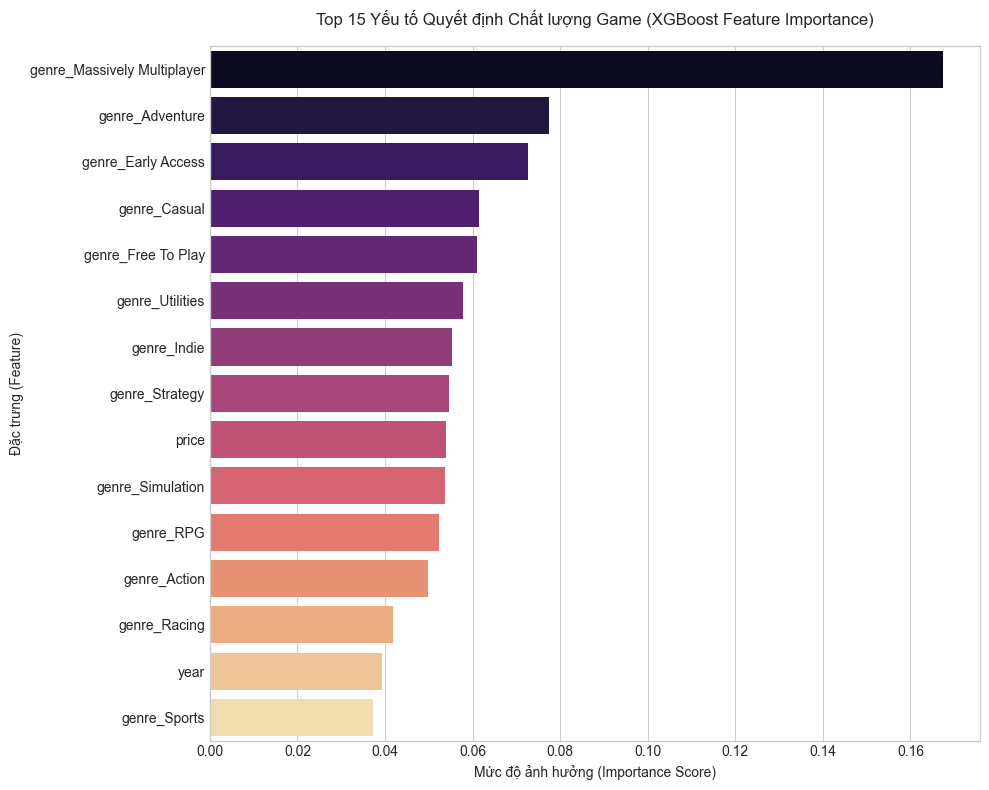

In [7]:
# Lấy Feature Importance từ mô hình XGBoost
feature_importance = xgb_model.feature_importances_

# Tạo DataFrame và sắp xếp
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Trực quan hóa Top 15 đặc trưng quan trọng nhất
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(15), palette='magma')
plt.title('Top 15 Yếu tố Quyết định Chất lượng Game (XGBoost Feature Importance)', pad=15)
plt.xlabel('Mức độ ảnh hưởng (Importance Score)')
plt.ylabel('Đặc trưng (Feature)')
plt.tight_layout()
plt.show()

## Kết luận Giai đoạn Machine Learning
1. **Wilson Score:** Việc áp dụng Wilson Score đã giúp dồn trọng tâm của mô hình vào việc dự đoán chất lượng thực chất, tránh bị nhiễu bởi các game ít người chơi.
2. **Hiệu suất Mô hình:** Bảng so sánh cho thấy các thuật toán Boosting/Ensemble (XGBoost, Random Forest) bắt được các quy luật phi tuyến tính tốt hơn Hồi quy Tuyến tính (Linear Regression).
3. **Insight từ Feature Importance:** Biểu đồ độ quan trọng chỉ ra rằng `price` (giá tiền), `year` (năm phát hành), và một số thể loại đặc thù (như Indie, Action, Casual) đóng vai trò cốt lõi định hình mức độ hài lòng của cộng đồng game thủ trên nền tảng Steam.